In [5]:
import pandas as pd

CDPR = pd.read_csv('CDPRusd.csv')
CDPR.set_index('date', inplace=True)
CDPR

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
date,,,,,,,,
2018-01-01,22.963517,22.963517,22.963517,22.963517,22.963517,0,0.0,0.0
2018-01-02,22.963517,22.963517,22.963517,22.963517,22.963517,0,0.0,0.0
2018-01-03,23.129232,23.673728,23.129232,23.200254,23.200254,212199,0.0,0.0
2018-01-04,23.436991,23.614544,23.022701,23.200254,23.200254,192525,0.0,0.0
2018-01-05,23.436991,23.531686,23.141069,23.436991,23.436991,120812,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-10-25,26.019989,26.468608,25.795678,26.319068,26.319068,406034,0.0,0.0
2023-10-26,26.231837,26.879844,25.895372,26.555841,26.555841,336988,0.0,0.0
2023-10-27,26.568302,27.166463,26.468608,26.593225,26.593225,255269,0.0,0.0


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Load the data
CDPR = pd.read_csv('CDPRusd.csv')
CDPR['date'] = pd.to_datetime(CDPR['date'])
CDPR.set_index('date', inplace=True)

# Split the data into training and validation sets
train_data = CDPR.loc[:'2020-08-27', 'Close']
valid_data = CDPR.loc['2020-08-28':'2021-01-27', 'Close']

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))

# Prepare the training data
X_train = []
y_train = []
for i in range(60, len(train_scaled)):
    X_train.append(train_scaled[i-60:i, 0])
    y_train.append(train_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape the data for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create the LSTM model
model = Sequential()
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=100))
model.add(Dense(units=1))

# Compile and train the model
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=30, batch_size=32)

# Prepare the validation data
inputs = CDPR.loc['2020-08-27':'2021-01-27', 'Close']
inputs = scaler.transform(inputs.values.reshape(-1, 1))
X_valid = []
for i in range(60, len(inputs)):
    X_valid.append(inputs[i-60:i, 0])
X_valid = np.array(X_valid)
X_valid = np.reshape(X_valid, (X_valid.shape[0], X_valid.shape[1], 1))

# Make predictions on the validation data
predictions = model.predict(X_valid)
predictions = scaler.inverse_transform(predictions)



Epoch 1/10
20/20 [==============================] - 7s 60ms/step - loss: 0.0298
Epoch 2/10
20/20 [==============================] - 1s 56ms/step - loss: 0.0030
Epoch 3/10
20/20 [==============================] - 1s 47ms/step - loss: 0.0020
Epoch 4/10
20/20 [==============================] - 1s 46ms/step - loss: 0.0016
Epoch 5/10
20/20 [==============================] - 1s 46ms/step - loss: 0.0015
Epoch 6/10
20/20 [==============================] - 1s 40ms/step - loss: 0.0014
Epoch 7/10
20/20 [==============================] - 1s 39ms/step - loss: 0.0014
Epoch 8/10
20/20 [==============================] - 1s 46ms/step - loss: 0.0014
Epoch 9/10
20/20 [==============================] - 1s 62ms/step - loss: 0.0014
Epoch 10/10
2/2 [==============================] - 1s 15ms/step


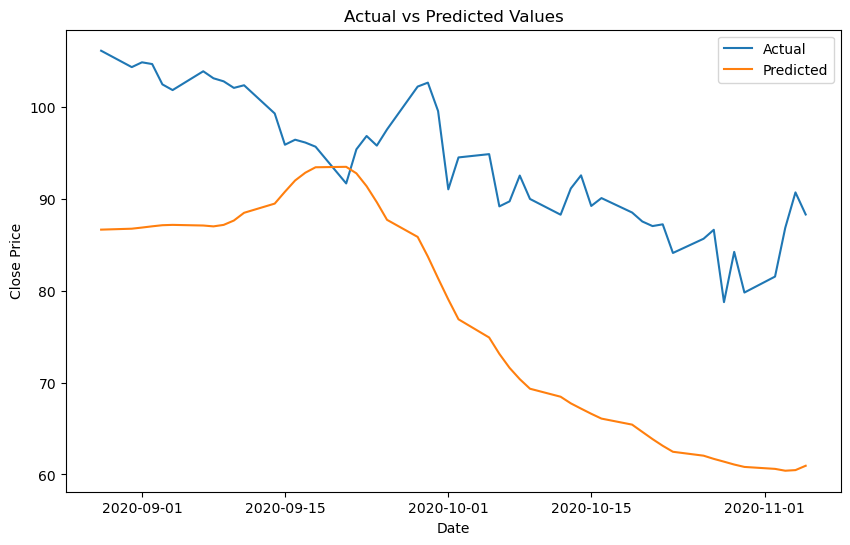

In [22]:
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(CDPR.loc['2020-08-28':'2021-01-27'].index[:50], CDPR.loc['2020-08-28':'2021-01-27', 'Close'][:50], label='Actual')
plt.plot(CDPR.loc['2020-08-28':'2021-01-27'].index[:50], predictions, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()
